**Name: Sahil Sanjay Kadam**  
**Student: 5144985**  
**Roll NO: 18**


# Practical 10: End-to-End Data Engineering Mini-Project
**Group Project: E-Commerce ETL Pipeline**

**Integrated Practicals:**
* **Prac 1 & 5:** Parsing APIs and CSVs, string matching, SQLite CRUD.
* **Prac 4:** Noise elimination, Feature Selection, EDA using Pandas/Matplotlib.
* **Prac 8:** PySpark transformations, joins, and aggregations.
* **Prac 7 & 9:** E-commerce ETL pipeline (validation, cleaning, loading).
* **Prac 3:** MongoDB operations (NoSQL storage).
* **Prac 6:** Apache Airflow DAG generation.
* **Prac 2:** Business Intelligence Reporting.

**1.Install Libraries**

In [1]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install -q pyspark==3.5.4 mongomock

import os
import sys

# Configure Java environment
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import sqlite3
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg
from sklearn.feature_selection import VarianceThreshold
import mongomock

**2.Generate Data for project**

In [2]:
# Generating mock e-commerce datasets
customers_data = {
    "customer_id": [1, 2, 3, 4, 5, 6],
    "age": [20, 25, 22, 105, 30, 24], # 105 is an outlier/noise
    "city": ["New York", "London", "Paris", "Tokyo", "Berlin", "Delhi"]
}
orders_data = {
    "order_id": [101, 102, 103, 104, 105, 106],
    "customer_id": [1, 2, 2, 3, 4, 5],
    "product_category": ["Electronics", "Clothing", "Electronics", "Home", "Clothing", "Home"],
    "amount": [999, 50, 500, 150, -20, 300], # -20 is invalid data
    "constant_feature": [1, 1, 1, 1, 1, 1] # Constant feature for selection test
}

pd.DataFrame(customers_data).to_csv("customers.csv", index=False)
pd.DataFrame(orders_data).to_csv("orders.csv", index=False)
print("Mock CSV files 'customers.csv' and 'orders.csv' created.")

Mock CSV files 'customers.csv' and 'orders.csv' created.


**3.Data Ingestion from API and CSV**

In [3]:
def extract_api_data(url):
    """Fetches data from a REST API and normalizes it."""
    response = requests.get(url, timeout=10)
    data = response.json()
    return pd.json_normalize(data)

# 1. API Extraction
api_url = "https://jsonplaceholder.typicode.com/users"
api_df = extract_api_data(api_url)
api_df = api_df[["id", "name", "email"]]
api_df.rename(columns={"id": "customer_id"}, inplace=True)

# 2. Flat File Extraction[cite: 1]
customers_csv = pd.read_csv("customers.csv")

# 3. Merge Data[cite: 1]
merged_customers = pd.merge(customers_csv, api_df, on="customer_id", how="left")
print("--- Merged API & CSV Data ---")
print(merged_customers.head())

--- Merged API & CSV Data ---
   customer_id  age      city              name                      email
0            1   20  New York     Leanne Graham          Sincere@april.biz
1            2   25    London      Ervin Howell          Shanna@melissa.tv
2            3   22     Paris  Clementine Bauch         Nathan@yesenia.net
3            4  105     Tokyo  Patricia Lebsack  Julianne.OConner@kory.org
4            5   30    Berlin  Chelsey Dietrich   Lucio_Hettinger@annie.ca


4.EDA, Noise Elimination, and Feature Selection

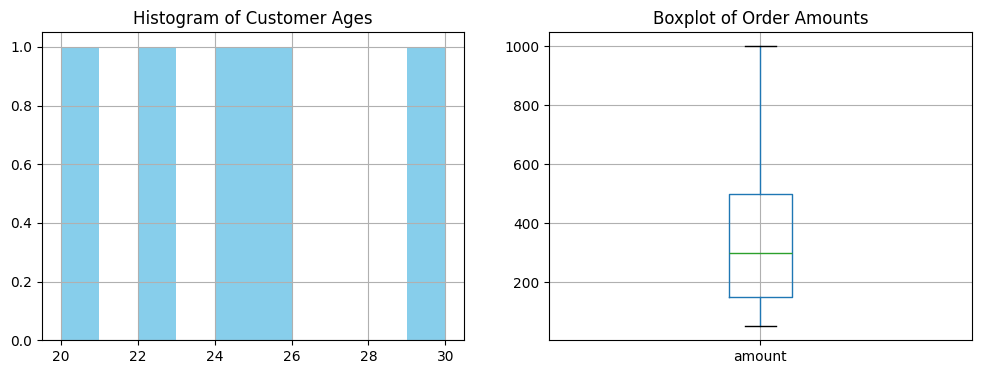

In [4]:
orders_df = pd.read_csv("orders.csv")

# 1. Noise Elimination (Outlier Removal)[cite: 1]
# Removing invalid negative amounts and extreme age outliers
orders_clean = orders_df[orders_df['amount'] > 0]

Q1 = merged_customers['age'].quantile(0.25)
Q3 = merged_customers['age'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
customers_clean = merged_customers[(merged_customers['age'] >= lower) & (merged_customers['age'] <= upper)]

# 2. Feature Selection (Removing zero-variance constants)[cite: 1]
selector = VarianceThreshold(threshold=0.0)
numerical_orders = orders_clean.select_dtypes(include=[np.number])
selector.fit(numerical_orders)
valid_cols = numerical_orders.columns[selector.get_support()].tolist()
orders_clean = orders_clean[valid_cols + ['product_category']] # Re-adding categorical

# 3. EDA - Histogram and Boxplot[cite: 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
customers_clean['age'].hist(ax=axes[0], color='skyblue')
axes[0].set_title("Histogram of Customer Ages")

orders_clean.boxplot(column=['amount'], ax=axes[1])
axes[1].set_title("Boxplot of Order Amounts")
plt.show()

# Save cleaned data to simulate Data Lake stage[cite: 1]
customers_clean.to_csv("clean_customers.csv", index=False)
orders_clean.to_csv("clean_orders.csv", index=False)

**5.PySpark Transformations & Aggregations.**


In [5]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg

# Safely remove any custom SPARK_HOME that points to a missing/broken manual directory
# This forces PySpark to fallback to its pip-installed native library binaries
if "SPARK_HOME" in os.environ:
    del os.environ["SPARK_HOME"]

# Initialize Spark Session natively
spark = SparkSession.builder \
    .appName("EcommerceETL") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# Load cleaned datasets into PySpark
df_customers = spark.read.csv("clean_customers.csv", header=True, inferSchema=True)
df_orders = spark.read.csv("clean_orders.csv", header=True, inferSchema=True)

print("--- Customers Schema ---")
df_customers.printSchema()

# Remove duplicates (if any)
df_orders = df_orders.dropDuplicates()

# Perform Join between customers and orders
df_joined = df_orders.join(df_customers, on="customer_id", how="inner")

# Calculate average sales by product category
avg_sales = df_joined.groupBy("product_category").agg(avg("amount").alias("avg_sales"))
print("--- Average Sales by Category ---")
avg_sales.show()

# Convert back to Pandas for Database loading
final_report_df = avg_sales.toPandas()

--- Customers Schema ---
root
 |-- customer_id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)

--- Average Sales by Category ---
+----------------+---------+
|product_category|avg_sales|
+----------------+---------+
|            Home|    225.0|
|     Electronics|    749.5|
|        Clothing|     50.0|
+----------------+---------+



**6.Relational Database Storage**

In [6]:
# Connect to SQLite Database[cite: 1]
conn = sqlite3.connect('ecommerce_warehouse.db')
cursor = conn.cursor()

# CRUD: Create Table[cite: 1]
cursor.execute('''
    CREATE TABLE IF NOT EXISTS SalesReport (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        category TEXT,
        average_sales REAL
    )
''')

# CRUD: Insert Data[cite: 1]
final_report_df.to_sql('SalesReport', conn, if_exists='replace', index=False)

# CRUD: Read Data[cite: 1]
print("--- Data Extracted from SQLite DB ---")
print(pd.read_sql_query("SELECT * FROM SalesReport", conn))

conn.close()

--- Data Extracted from SQLite DB ---
  product_category  avg_sales
0             Home      225.0
1      Electronics      749.5
2         Clothing       50.0


**7.NoSQL Storage - MongoDB Operations**

In [7]:
# Initialize Mock MongoDB Client
client = mongomock.MongoClient()
db = client.ecommerce_db
items_collection = db.items
products_collection = db.products

# Step 1: Insert Single Document[cite: 2]
res_single = items_collection.insert_one({"name": "laptop", "price": 999})
print(f"Single Insert Acknowledged: {res_single.acknowledged}")

# Step 2: View Inserted Document[cite: 2]
print("\nItems Collection:")
for item in items_collection.find():
    print(item)

# Step 3: Insert Multiple Documents[cite: 2]
res_multi = products_collection.insert_many([
    {"name": "phone", "price": 500, "stock": 10},
    {"name": "tablet", "price": 300, "stock": 5},
    {"name": "watch", "price": 150, "stock": 0}
])
print(f"\nMultiple Insert Acknowledged: {res_multi.acknowledged}")

# Step 4: View Products (Formatted as Dictionary/JSON)[cite: 2]
print("\nProducts Collection:")
for product in products_collection.find():
    print(product)

Single Insert Acknowledged: True

Items Collection:
{'name': 'laptop', 'price': 999, '_id': ObjectId(fc83850a-c2df-11f1-bff3-0242ac1c000c)}

Multiple Insert Acknowledged: True

Products Collection:
{'name': 'phone', 'price': 500, 'stock': 10, '_id': ObjectId(fc8419c0-c2df-11f1-bff3-0242ac1c000c)}
{'name': 'tablet', 'price': 300, 'stock': 5, '_id': ObjectId(fc841e2a-c2df-11f1-bff3-0242ac1c000c)}
{'name': 'watch', 'price': 150, 'stock': 0, '_id': ObjectId(fc842032-c2df-11f1-bff3-0242ac1c000c)}


**8.Pipeline Orchestration - Apache Airflow DAG**

In [8]:
%%writefile ecommerce_dag.py
from datetime import datetime, timedelta
from airflow import DAG
from airflow.operators.bash import BashOperator
from airflow.operators.empty import EmptyOperator

# Default arguments for workflow execution[cite: 1]
default_args = {
    "owner": "data_engineering_lab",
    "start_date": datetime(2026, 1, 1),
    "retries": 1,
    "retry_delay": timedelta(minutes=5),
}

# Define DAG context[cite: 1]
with DAG(
    "ecommerce_etl_orchestration",
    default_args=default_args,
    description="End-to-end pipeline execution",
    schedule_interval=timedelta(days=1),
    catchup=False,
) as dag:

    start_pipeline = EmptyOperator(task_id="start_pipeline")

    run_etl = BashOperator(
        task_id="run_pyspark_etl",
        bash_command="python3 /path/to/etl_script.py", # Represents running the above code
    )

    log_success = BashOperator(
        task_id="log_pipeline_success",
        bash_command='echo "ETL Execution completed successfully at $(date)"',
    )

    start_pipeline >> run_etl >> log_success

Overwriting ecommerce_dag.py


**9.Business Intelligence & Reporting**

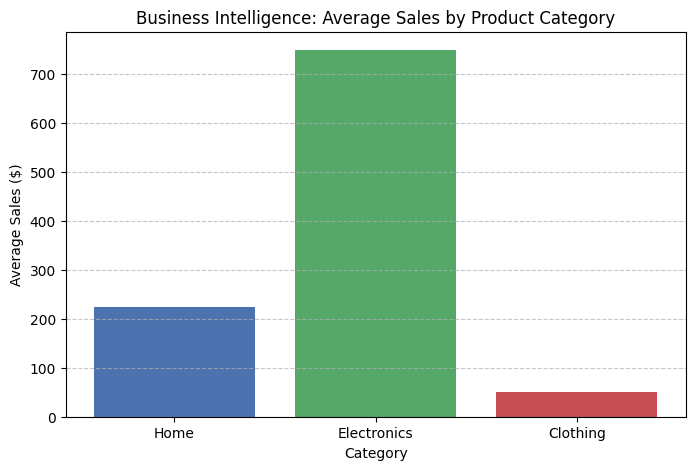


--- Pipeline Execution Complete. Data successfully cleaned, transformed, stored, and visualized. ---


In [9]:
# Generate Executive Report
plt.figure(figsize=(8, 5))
plt.bar(final_report_df['product_category'], final_report_df['avg_sales'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.title("Business Intelligence: Average Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Sales ($)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display final dashboard widget
plt.show()
print("\n--- Pipeline Execution Complete. Data successfully cleaned, transformed, stored, and visualized. ---")